In [1]:
from gradio_client import Client   # for api use

import ast                         # for text to list conversion (make data useful)
import pandas as pd                # for easy data use; you can use polars or whatever you like

# start 8:14pm

# Accessing the API

Accessing the API is simple. You pass your key to the client, and then you will see a message the API has loaded.

In [2]:
token = '../api_creds/vi_key_1.csv'

# load my key
df = pd.read_csv(token) # easy and lazy lol; using pandas anyway ;p
api_key = df['key'][0]  # easy and lazy lol; using pandas anyway ;p

# connect to api
client = Client("verdantintel/verdanteye", token=api_key)

Loaded as API: https://verdantintel-verdanteye.hf.space


# Helper Function

In [3]:
def ask_api(client, question):

    answer = client.predict(question=question, api_name="/predict")
    
    answer = ast.literal_eval(answer)

    return answer

# Searching for Data

In [5]:
question = 'what has been seen in the last six hours?'

answer = ask_api(client, question)
len(answer)

1409

In [6]:
answer[0]

{'claim': 'A rabid beaver attacked an 8-year-old boy in a New Jersey park.',
 'url': 'https://katv.com/news/nation-world/rabid-beaver-attacks-8-year-old-boy-in-new-jersey-park-reports-rabies-bitten-bite-mahwah-township-health-department-medical-treatment-animals-wildlife-bats-coyotes-foxes-raccoons-skunks-vaccine-vaccination',
 'domain': 'katv.com',
 'url_domain': 'katv.com',
 'date_added': '2026-05-06 16:56:20'}

In [7]:
df = pd.DataFrame(answer)
df['date_added'] = pd.to_datetime(df['date_added'], utc=True)
df['date_added'] = df['date_added'].dt.tz_convert('America/Los_Angeles') # put into my timezone
df.sort_values('date_added', ascending=False, inplace=True)
df.head()

,claim,url,domain,url_domain,date_added
0,A rabid beaver attacked an 8-year-old boy in a...,https://katv.com/news/nation-world/rabid-beave...,katv.com,katv.com,2026-05-06 09:56:20-07:00
3,A Florida K-9 dog rescued a missing autistic t...,https://www.breitbart.com/local/2026/05/05/wat...,breitbart.com,breitbart.com,2026-05-06 09:56:20-07:00
4,First Lady Melania Trump honors American milit...,https://www.breitbart.com/politics/2026/05/06/...,breitbart.com,breitbart.com,2026-05-06 09:56:20-07:00
1,TGJONES launches a book contest called Bitesiz...,https://www.dailyrecord.co.uk/in-your-area/lan...,dailyrecord.co.uk,dailyrecord.co.uk,2026-05-06 09:56:20-07:00
2,Ohio brothers were sentenced to over two decad...,https://www.breitbart.com/crime/2026/05/06/ohi...,breitbart.com,breitbart.com,2026-05-06 09:56:20-07:00


In [8]:
df.to_csv('claim_edgelist.csv', header=True, index=False)

In [9]:
df.tail() # six hours

,claim,url,domain,url_domain,date_added
1404,Suggestions for gifts for Mother's Day related...,https://www.corriere.it/cook/news/cards/cosa-r...,corriere.it,corriere.it,2026-05-06 03:59:31-07:00
1405,"Current treatments for diabetes in Italy, alon...",https://www.corriere.it/salute/diabete/26_magg...,corriere.it,corriere.it,2026-05-06 03:59:31-07:00
1406,Dani Alves is facing imprisonment related to a...,https://www.corriere.it/sport/26_maggio_06/dan...,corriere.it,corriere.it,2026-05-06 03:59:31-07:00
1407,Pupils are skipping class to protest a change ...,https://www.gbnews.com/news/lincolnshire-news-...,gbnews.com,gbnews.com,2026-05-06 03:58:33-07:00
1408,Three people were evacuated from a cruise ship...,https://abc7chicago.com/post/3-evacuated-off-c...,abc7chicago.com,abc7chicago.com,2026-05-06 03:58:08-07:00


In [10]:
df.shape

(1409, 5)

# Clustering

Clustering is useful for seeing the kinds of things that are happening. If you want to do trend analysis, start with clustering or filtering. You will want to have clustering in your skillset/toolset. Here is my graph+nlp approach, my own approach.

Tweak the similarity threshold to get what you want. 1 is exact match. 0 is no match. 0.5-0.8 is typically pretty sweet, but it depends on what you are doing. Sometimes lower is useful. Sometimes very high is useful. Be thoughtful about what you are trying to do and it will make sense. Ask me if you would like to learn more.

In [11]:
import pandas as pd
import numpy as np
import networkx as nx
import community as community_louvain

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [12]:
def cluster_text(texts, similarity_threshold=0.5):

    vectorizer = TfidfVectorizer(
        ngram_range=(1, 2),
        lowercase=True,
        sublinear_tf=True
    )

    tfidf_matrix = vectorizer.fit_transform(texts)

    similarity_matrix = cosine_similarity(tfidf_matrix, tfidf_matrix)
    adj_matrix = (similarity_matrix > similarity_threshold).astype(int)

    G = nx.from_numpy_array(adj_matrix)
    partition = community_louvain.best_partition(G, resolution=0.5, random_state=1337) 

    return list(partition.values())

In [13]:
df.head()

,claim,url,domain,url_domain,date_added
0,A rabid beaver attacked an 8-year-old boy in a...,https://katv.com/news/nation-world/rabid-beave...,katv.com,katv.com,2026-05-06 09:56:20-07:00
3,A Florida K-9 dog rescued a missing autistic t...,https://www.breitbart.com/local/2026/05/05/wat...,breitbart.com,breitbart.com,2026-05-06 09:56:20-07:00
4,First Lady Melania Trump honors American milit...,https://www.breitbart.com/politics/2026/05/06/...,breitbart.com,breitbart.com,2026-05-06 09:56:20-07:00
1,TGJONES launches a book contest called Bitesiz...,https://www.dailyrecord.co.uk/in-your-area/lan...,dailyrecord.co.uk,dailyrecord.co.uk,2026-05-06 09:56:20-07:00
2,Ohio brothers were sentenced to over two decad...,https://www.breitbart.com/crime/2026/05/06/ohi...,breitbart.com,breitbart.com,2026-05-06 09:56:20-07:00


In [14]:
df['cluster'] = cluster_text(df['claim'], similarity_threshold=0.4) # reducing to capture broader topics
df.head()

,claim,url,domain,url_domain,date_added,cluster
0,A rabid beaver attacked an 8-year-old boy in a...,https://katv.com/news/nation-world/rabid-beave...,katv.com,katv.com,2026-05-06 09:56:20-07:00,0
3,A Florida K-9 dog rescued a missing autistic t...,https://www.breitbart.com/local/2026/05/05/wat...,breitbart.com,breitbart.com,2026-05-06 09:56:20-07:00,1
4,First Lady Melania Trump honors American milit...,https://www.breitbart.com/politics/2026/05/06/...,breitbart.com,breitbart.com,2026-05-06 09:56:20-07:00,2
1,TGJONES launches a book contest called Bitesiz...,https://www.dailyrecord.co.uk/in-your-area/lan...,dailyrecord.co.uk,dailyrecord.co.uk,2026-05-06 09:56:20-07:00,3
2,Ohio brothers were sentenced to over two decad...,https://www.breitbart.com/crime/2026/05/06/ohi...,breitbart.com,breitbart.com,2026-05-06 09:56:20-07:00,4


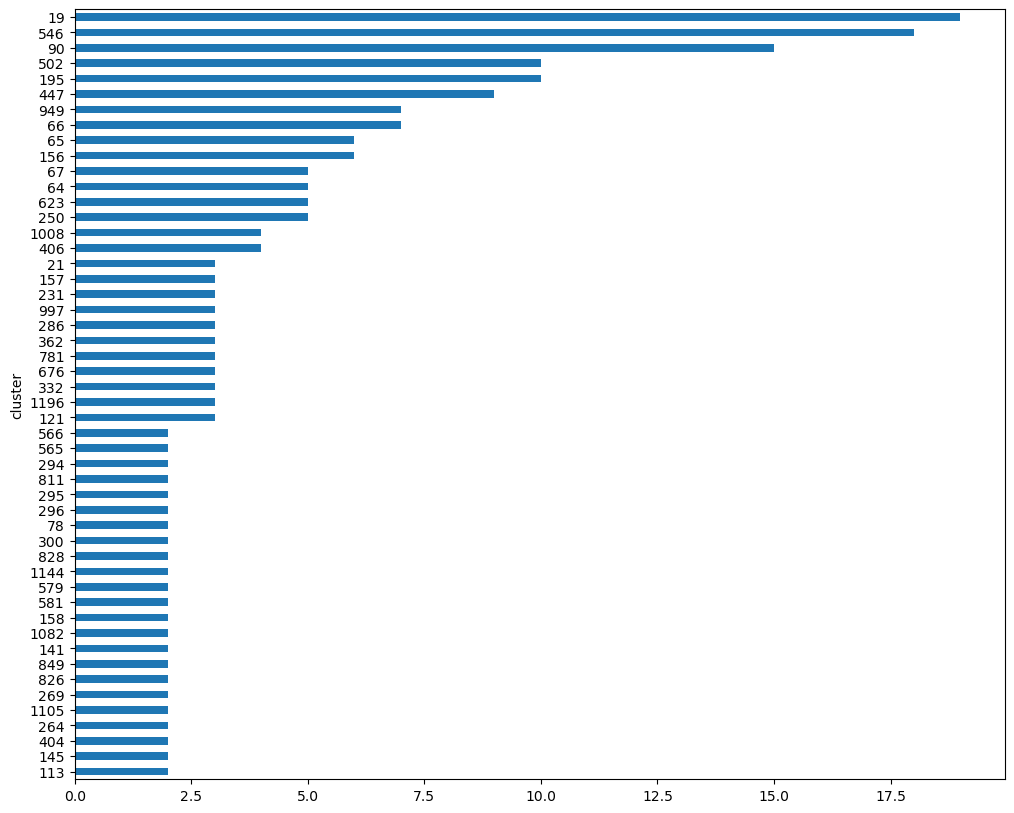

In [15]:
df['cluster'].value_counts()[0:50].plot.barh(figsize=(12,10)).invert_yaxis()

In [16]:
top_clusters = df['cluster'].value_counts().index.values
top_clusters

array([ 19, 546,  90, ..., 431, 432,  31], dtype=int64)

In [17]:
for cluster in top_clusters:
    
    print('cluster: {}'.format(cluster))
    
    cluster_data = df[df['cluster']==cluster].head(20)['claim'].values
    print(cluster_data)
    
    print()

cluster: 19
['News article' 'News article' 'News article' 'News article'
 'News article' 'News article' 'News article' 'News article'
 'News article' 'News article' 'News article' 'News article'
 'News article link' 'News article link' 'News article link'
 'News article link' 'News article link'
 'News article related to events in Madrid'
 'News article related to events in the Basque Country']

cluster: 546
['Evacuation of patients from a cruise due to hantavirus cases'
 '3 patients suspected of hantavirus evacuated'
 'Three patients are being evacuated to Europe due to a hantavirus outbreak on a cruise ship.'
 'Three patients are being evacuated to Europe from a cruise ship due to a hantavirus outbreak.'
 'Three patients suspected of having hantavirus'
 'Sick passengers were evacuated from a cruise ship due to a hantavirus outbreak.'
 '3 people were evacuated from a cruise ship due to a suspected hantavirus cluster.'
 'A hantavirus outbreak has led to the evacuation of patients from 

['Duo suspected of motorcycle theft arrested']

cluster: 796
['Child attacked by rabid castor in lake in the USA']

cluster: 794
['Roberto Savi, the killer of Uno Bianca, is in services']

cluster: 827
['Link to an event on the McMenamins website']

cluster: 793
["Andrea Sempio leaves the prosecutor's office in the Garlasco case"]

cluster: 792
['Title bout between Sundowns and Pirates enters championship']

cluster: 791
['The Wits Standard Bank piano festival returns']

cluster: 829
['Tickets for Wednesday Night Social event with cigars and music']

cluster: 830
['Tickets for Light Once Lost with guests at High Limit Room event']

cluster: 795
['Crisis aboard MV Hondius due to deadly hantavirus outbreak']

cluster: 799
['RCMP searching for two missing youths in Grand Falls-Windsor']

cluster: 822
['Invitation to a blood donation campaign']

cluster: 798
['Families are looking beyond Ottawa due to rising housing costs']

cluster: 808
['Police raid home industry involved in narcotics wi

['Warns about a dangerous virus on a cruise ship that may be mistaken for the flu.']

cluster: 666
['Reports that the WHO fears a new pandemic due to slow and disorganized responses.']

cluster: 664
['Claims that there has been no evidence of hantavirus transmission between people according to WHO.']

cluster: 663
['A driver is accused of chasing a child on a bike down a sidewalk before attempting to break into a home.']

cluster: 661
["A man is nicknamed 'Stumpy' because he has four limbs."]

cluster: 654
['Announcement of an event related to North Texas Growers']

cluster: 660
['A huge Rambo knife was used in a murder case.']

cluster: 659
['Tickets are available for the 52nd annual Galveston Historic Homes Tour.']

cluster: 658
['Halifax Hoopers are playing against Tricity Tide']

cluster: 657
['Free tickets available for Azazie Halifax pop-up event on May 30, 2026']

cluster: 656
['Learn Chinese dumpling wrapping techniques at IKEA Halifax']

cluster: 655
['Explanation of hantaviru

['Information regarding hantavirus']

cluster: 1094
['Announcement of a Pennsylvania conference for women']

cluster: 1109
['Cocaine kingpins sponsored a Motherwell football club']

cluster: 1111
['Discussion on the evolving forms of Holocaust denial and its dangers.']

cluster: 1092
['Arrest of a former football coach accused of sexual abuse']

cluster: 1120
['Antisemitic assaults have reached record levels.']

cluster: 1126
['Event scheduled for Hagerstown Flying Boxcars vs Long Island Ducks on May 6, 2026.']

cluster: 1125
['Bus crash involving a fuel truck kills 16 people, driver suspected to have lost control.']

cluster: 1124
['10 Indonesian nationals arrested in Saudi Arabia for offering illegal hajj packages.']

cluster: 1123
['Mass layoff threats loom over five industrial sectors.']

cluster: 1122
['Surveillance tools are designed for border control.']

cluster: 1121
['Protest groups are blocking access to Russian facilities.']

cluster: 1119
['An 80-year-old woman was murdere

['MPs raise alarm over border health gaps after hantavirus detection.']

cluster: 1054
['Farmingdale State College plant sale draws crowds with rare offerings.']

cluster: 903
['Information about a fair event at a ballpark']

cluster: 950
['Anambra police arrest notorious cultist and recover arms']

cluster: 956
['Asda, Morrisons, and Tesco confirm free giveaway to parents']

cluster: 955
['Dozens of WCape anti-gang unit officers facing probes']

cluster: 954
['Two chiefs among the 15 new police officers arrested for']

cluster: 953
['Explosion in café causes six injuries in Seixal']

cluster: 952
['Five burglars arrested after break-in in Schoorl']

cluster: 951
['Resident shot at home in Amsterdam Southeast']

cluster: 948
['A double-decker bus associated with TJ Maxx caught fire in the suburbs of Chicago, as shown in a video from Chopper 7.']

cluster: 958
['First case of screwworm in Mexico City']

cluster: 947
['An elderly woman died after eating poisoned mushroom risotto at a res

['Difficult terrain and military training may complicate manhunt for a Tennessee suspect.']

cluster: 999
['Record high of antisemitic assaults in the US according to the Anti-Defamation League.']

cluster: 636
['Covers a live funeral for an Ontario police officer who was killed.']

cluster: 0
['A rabid beaver attacked an 8-year-old boy in a New Jersey park.']

cluster: 634
['Discusses a scandal at a college involving a viral clip.']

cluster: 210
['Victoria Beckham denies accusations of being a pushy mother.']

cluster: 216
['Senate Republicans propose a large budget related to immigration.']

cluster: 215
['A man has been charged after shooting at law enforcement.']

cluster: 214
['A person was convicted for torturing an animal.']

cluster: 213
['Marius wants to move back to his mother.']

cluster: 212
['Many children have had disturbing experiences on Discord.']

cluster: 211
['Pensacola chief discusses the chaotic Cordova Mall takeover.']

cluster: 209
['A teacher who survived a kn

['Details about a British woman married to a death row rapper']

cluster: 165
["Americans' perceptions of crime do not align with actual crime trends."]

cluster: 163
['Testimony of a citizen after Andrie Yunus was splashed with acid, clothing destroyed']

cluster: 633
['Reports on the vandalism of a monument dedicated to Eddy Merckx.']

cluster: 49
['Controversy over housing project']

cluster: 55
['Claim that no bacterial infection was found in the bodies of four Mumbai family members who died after eating watermelon.']

cluster: 54
['Claim of a Texas man facing charges for a shootout involving the Secret Service at the Washington Monument.']

cluster: 53
["Claim of an FBI raid on a Virginia state senator's office related to business and cannabis."]

cluster: 52
['Case of abuse reported']

cluster: 51
['Risk of contamination on cruise']

cluster: 50
['Heart attack alert for women']

cluster: 48
["Protest against Russia's participation"]

cluster: 57
["Claim about a poetry workshop ti

['A 28-year-old woman is posing as a teen student at a high school in NYC and has been exposed by her social media profile.']

cluster: 123
['A Texas restaurant owner and their two children were involved in a murder-suicide incident.']

cluster: 122
['Kayakers drowned in Ponquogue, Hampton Bays.']

cluster: 92
['Report on police activity related to a drug investigation.']

cluster: 99
["Public viewing event for 'The L Word: Generation Q' series."]

cluster: 98
['Event for practicing English language skills.']

cluster: 97
['Event for a specific meetup group.']

cluster: 96
['The police distribute a protocol for agents to act against the virus with guidelines on masks and ventilation.']

cluster: 95
['The housing crisis also affects health.']

cluster: 94
['Event announcement for an R&B and hip hop party in Hollywood.']

cluster: 91
['Event hosted at Denver Library']

cluster: 120
['A 9-year-old boy died after a tree collapsed on a playground in Massachusetts.']

cluster: 89
['The ADL r

["Request for sharing photos and videos related to Mother's Day 2026."]

cluster: 391
['A British individual was caught on CCTV stabbing a receptionist at a luxury hotel in Bali.']

cluster: 390
["A teacher sexually assaulted and murdered a baby, with a recorded moment of the incident revealing the child's suffering."]

cluster: 389
['A married boss harassed a younger female colleague by comparing his feelings to a Kylie Minogue song, as heard at a tribunal.']

cluster: 387
['Willy Bardon requests a review of the case involving Elodie Kulik']

cluster: 380
["Lima Duarte's comments spark protests"]

cluster: 386
['Children protest with their parents in the streets']

cluster: 385
['Hélène de Fougerolles recounts near-drowning incident']

cluster: 384
['WHO searching for the zero patient for hantavirus']

cluster: 383
['Murder trial involving a son and stepmother']

cluster: 382
['Rain delays garbage collection in Bogotá']

cluster: 381
["Heartbreaking story from Crisanto Balanta's famil

In [18]:
# end 8:15pm